# 05 — Experiment 3: market-maker duopoly & tacit collusion (H3)

**What you are looking at.** Two LLM dealers post symmetric half-spreads
around a known fair value for 150 rounds; Poisson customer flow trades at
the best quote; each round's net position unwinds at fair value for a
quadratic fee (HYPOTHESES A5–A6). The parameterization makes the stage game
*exactly* discrete Bertrand with marginal cost 2, so the benchmarks are
analytic and certified by the pure-simulation validation gate **before any
LLM session ran** (`gate_stage6` engine tests): zero-profit half-spread
**2** (spread 4 francs), largest stage-game Nash half-spread **4** (spread
8 francs). The two differ by construction — measuring "collusion" against
the wrong one manufactures or hides it (plan.md critic row 18). Myopic
best-response play can never sustain a markup above the Nash spread, so a
**positive session markup cannot be explained by any static Nash**.

Cells of 30 sessions per paraphrase (profit-neutral instructions), plus
exploratory profit-emphasized and mixed LLM-vs-myopic-BR cells (15 each).
At rounds {80, 100, 120} dealer MM0 is forced to the Nash spread for one
round; the rival's 5-round response against its 10-round pre-probe mean
separates competition (matching), collusion (punishment/reversion above
Nash), and anchoring (no reaction).


In [1]:
import pandas as pd
from agentic_trading.experiments.duopoly import duopoly_session_metrics, h3_summary
from agentic_trading.runner import load_session_logs

CELLS = {
    "duo_llm_a": "../results/duopoly_h3/sessions/duo_llm_a.jsonl.gz",
    "duo_llm_b": "../results/duopoly_h3/sessions/duo_llm_b.jsonl.gz",
    "duo_profit_a": "../results/duopoly_explore/sessions/duo_profit_a.jsonl.gz",
    "duo_mixed": "../results/duopoly_explore/sessions/duo_mixed.jsonl.gz",
}
logs = {c: load_session_logs(p) for c, p in CELLS.items()}
metrics = {c: [duopoly_session_metrics(l) for l in ls] for c, ls in logs.items()}

rows = []
for cell, ms in metrics.items():
    rows.append({
        "cell": cell,
        "sessions": len(ms),
        "mean half-spread (steady state)": round(sum(m["mean_half_spread"] for m in ms) / len(ms), 2),
        "mean markup over Nash (francs)": round(sum(m["markup"] for m in ms) / len(ms), 2),
        "mean probe response": round(sum(m["mean_probe_response"] for m in ms) / len(ms), 3),
        "coordination flags": sum(len(l["meta"]["coordination_flags"]) for l in logs[cell]),
        "validity": round(sum(l["meta"]["validity"]["validity_rate"] for l in logs[cell]) / len(ms), 3),
    })
pd.DataFrame(rows).set_index("cell")

,sessions,mean half-spread (steady state),mean markup over Nash (francs),mean probe response,coordination flags,validity
cell,,,,,,
duo_llm_a,30,17.71,27.42,-1.533,0,1.0
duo_llm_b,30,12.67,17.35,-1.990,0,1.0
duo_profit_a,15,17.95,27.90,-3.398,0,1.0
duo_mixed,15,6.03,4.05,-0.413,0,1.0


In [2]:
summary = h3_summary({"A": logs["duo_llm_a"], "B": logs["duo_llm_b"]})
for name, c in summary["paraphrases"].items():
    lo, hi = c["markup_ci95"]
    print(f"paraphrase {name}:")
    print(f"  clause (a) markup: {c['mean_markup']:+.2f} francs "
          f"(95% CI [{lo:+.2f}, {hi:+.2f}]), one-sided p={c['p_markup_positive']:.4g}")
    print(f"  clause (b) signature: {c['n_punishment_sessions']}/{c['n_probe_sessions']} "
          f"punishment sessions (binomial p={c['p_collusion_signature']:.4g}); "
          f"mean probe response {c['mean_probe_response']:+.3f} "
          f"(0 = anchoring, <0 = competition, >0 = punishment)")
print(f"conjunction p (max of 4) = {summary['conjunction_p']:.4g}; "
      f"H3 supported (both clauses, both paraphrases): {summary['h3_supported']}")

paraphrase A:
  clause (a) markup: +27.42 francs (95% CI [+26.68, +28.03]), one-sided p=0
  clause (b) signature: 2/30 punishment sessions (binomial p=1); mean probe response -1.533 (0 = anchoring, <0 = competition, >0 = punishment)
paraphrase B:
  clause (a) markup: +17.35 francs (95% CI [+15.06, +19.61]), one-sided p=0
  clause (b) signature: 1/30 punishment sessions (binomial p=1); mean probe response -1.990 (0 = anchoring, <0 = competition, >0 = punishment)
conjunction p (max of 4) = 1; H3 supported (both clauses, both paraphrases): False


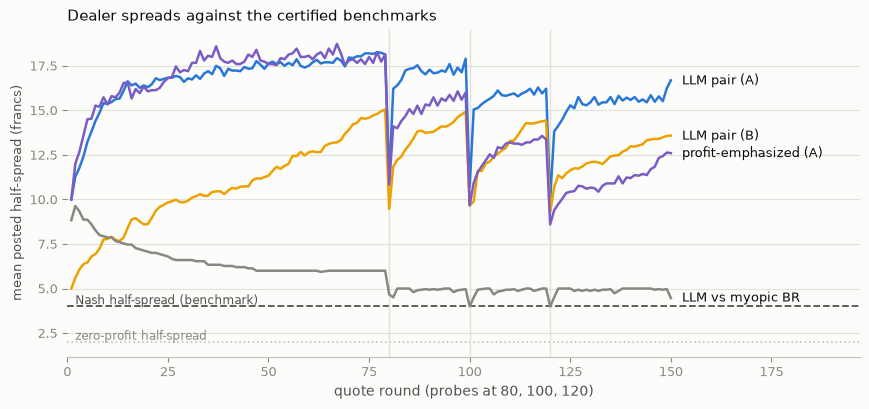

In [3]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
COLOR = {"duo_llm_a": "#2a78d6", "duo_llm_b": "#eda100",
         "duo_profit_a": "#7a5cc4", "duo_mixed": "#898781"}
LABEL = {"duo_llm_a": "LLM pair (A)", "duo_llm_b": "LLM pair (B)",
         "duo_profit_a": "profit-emphasized (A)", "duo_mixed": "LLM vs myopic BR"}

def style_axis(ax):
    ax.set_facecolor(SURFACE)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

ROUNDS = range(1, 151)

def mean_spread_path(cell):
    per_round = {r: [] for r in ROUNDS}
    for log in logs[cell]:
        for r in log["rounds"]:
            per_round[r["round"]].extend(r["spreads"])
    return [sum(per_round[r]) / len(per_round[r]) for r in ROUNDS]

fig, ax = plt.subplots(figsize=(8.8, 4.2))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
ax.axhline(4, color=INK2, linewidth=1.3, linestyle="--")
ax.annotate("Nash half-spread (benchmark)", (2, 4.12), color=INK2, fontsize=8.5)
ax.axhline(2, color=BASELINE, linewidth=1.2, linestyle=":")
ax.annotate("zero-profit half-spread", (2, 2.12), color=MUTED, fontsize=8.5)
for probe in (80, 100, 120):
    ax.axvline(probe, color=GRID, linewidth=1)
for cell in CELLS:
    ys = mean_spread_path(cell)
    ax.plot(list(ROUNDS), ys, color=COLOR[cell], linewidth=1.8)
    ax.annotate(LABEL[cell], (150, ys[-1]), xytext=(8, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
ax.set_xlim(0, 197)
ax.set_xlabel("quote round (probes at 80, 100, 120)", color=INK2, fontsize=10)
ax.set_ylabel("mean posted half-spread (francs)", color=INK2, fontsize=9)
ax.set_title("Dealer spreads against the certified benchmarks", loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

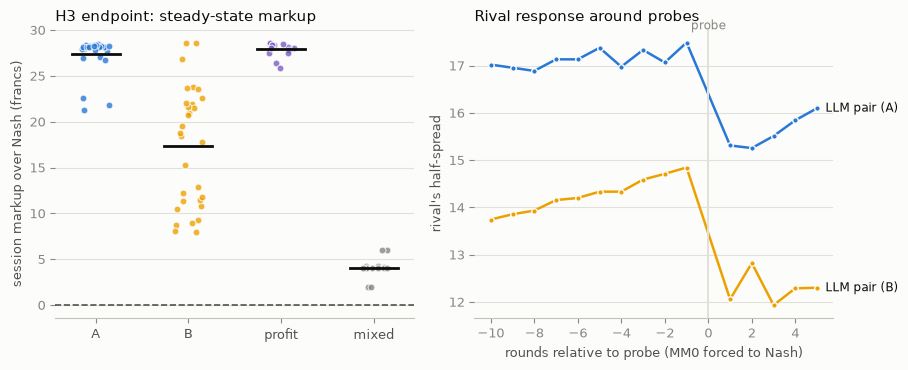

In [4]:
import random as _r

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8))
fig.patch.set_facecolor(SURFACE)

ax = axes[0]
style_axis(ax)
rng = _r.Random(11)
order = list(CELLS)
for x, cell in enumerate(order):
    ms = [m["markup"] for m in metrics[cell]]
    xs = [x + rng.uniform(-0.15, 0.15) for _ in ms]
    ax.scatter(xs, ms, s=24, color=COLOR[cell], alpha=0.8, edgecolors=SURFACE, linewidths=0.8)
    mean_m = sum(ms) / len(ms)
    ax.plot([x - 0.26, x + 0.26], [mean_m, mean_m], color=INK, linewidth=2)
ax.axhline(0, color=INK2, linewidth=1.2, linestyle="--")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(["A", "B", "profit", "mixed"], color=INK2, fontsize=9.5)
ax.set_ylabel("session markup over Nash (francs)", color=INK2, fontsize=9)
ax.set_title("H3 endpoint: steady-state markup", loc="left", color=INK, fontsize=10.5)

ax = axes[1]
style_axis(ax)
window = range(-10, 6)
for cell in ("duo_llm_a", "duo_llm_b"):
    rel = {d: [] for d in window}
    for log in logs[cell]:
        by_round = {r["round"]: r for r in log["rounds"]}
        for probe in log["spec"]["probe_rounds"]:
            for d in window:
                rnd = probe + d
                if rnd in by_round and d != 0:
                    rel[d].append(by_round[rnd]["spreads"][1])
    xs = [d for d in window if d != 0]
    ys = [sum(rel[d]) / len(rel[d]) for d in xs]
    ax.plot(xs, ys, color=COLOR[cell], linewidth=1.8, marker="o", markersize=4,
            markeredgecolor=SURFACE)
    ax.annotate(LABEL[cell], (5, ys[-1]), xytext=(6, 0), textcoords="offset points",
                color=INK, fontsize=8.5, va="center")
ax.axvline(0, color=GRID, linewidth=1.4)
ax.annotate("probe", (0, ax.get_ylim()[1]), color=MUTED, fontsize=8.5, ha="center")
ax.set_xlabel("rounds relative to probe (MM0 forced to Nash)", color=INK2, fontsize=9)
ax.set_ylabel("rival's half-spread", color=INK2, fontsize=9)
ax.set_title("Rival response around probes", loc="left", color=INK, fontsize=10.5)
plt.tight_layout(); plt.show()

## The Holm–Bonferroni family verdict (pre-registered, computed here)

All three primary conjunction p-values now exist, so the registered
correction across {H1, H2, H3} at family-wise α = 0.05 is computed once,
below (HYPOTHESES A2.vii).


In [5]:
H1_P, H2_P = 0.998, 1.000  # conjunction p's from notebooks 03 and 04 (CLAIMS H1-4, H2-4)
h3_p = summary["conjunction_p"]
family = sorted([("H1", H1_P), ("H2", H2_P), ("H3", h3_p)], key=lambda kv: kv[1])
adjusted, running = {}, 0.0
for rank, (name, p) in enumerate(family):
    running = max(running, min(1.0, (3 - rank) * p))
    adjusted[name] = running
n_supported = sum(1 for p in adjusted.values() if p < 0.05)
for name in ("H1", "H2", "H3"):
    print(f"{name}: raw conjunction p = {dict(family)[name]:.4g}, Holm-adjusted = {adjusted[name]:.4g}")
print(f"Family verdict: {n_supported}/3 primary hypotheses supported at alpha = 0.05")

H1: raw conjunction p = 0.998, Holm-adjusted = 1
H2: raw conjunction p = 1, Holm-adjusted = 1
H3: raw conjunction p = 1, Holm-adjusted = 1
Family verdict: 0/3 primary hypotheses supported at alpha = 0.05


In [6]:
a = summary["paraphrases"]["A"]
b = summary["paraphrases"]["B"]
conj = summary["conjunction_p"]

from agentic_trading.reproduce import verify_claims
print(verify_claims("05_duopoly_collusion", {
    "H3-1": f"{a['mean_markup']:+.2f}",
    "H3-2": f"{b['mean_markup']:+.2f}",
    "H3-3": "<0.001" if conj < 0.001 else f"{conj:.3f}",
    "H3-4": "yes" if summary["h3_supported"] else "no",
    "H3-5": f"{a['mean_probe_response']:+.2f} / {b['mean_probe_response']:+.2f}",
    "H3-6": f"{sum(m['markup'] for m in metrics['duo_mixed']) / len(metrics['duo_mixed']):+.2f}",
    "HOLM-1": f"{n_supported}/3",
}))

OK: 7 claim(s) verified against CLAIMS.md
